In [1]:
import random
import time
import numpy as np
import torch

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

print("Training Images:", len(train_data))
print("Testing Images:", len(test_data))

Training Images: 60000
Testing Images: 10000


In [4]:
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=256,
    shuffle=False
)

print("DataLoaders Created Successfully!")

DataLoaders Created Successfully!


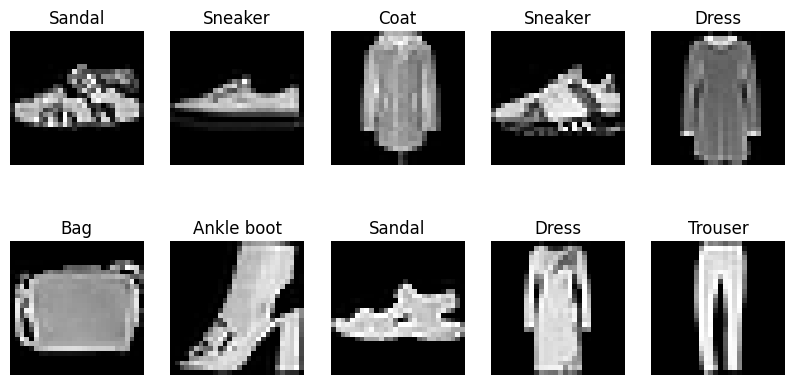

In [5]:
import matplotlib.pyplot as plt

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.show()

In [6]:
class FashionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

        self.activation = nn.ReLU()

    def forward(self, x):

        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)

        return logits

In [7]:
model = FashionMLP().to(device)

print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)


In [8]:
total_params = sum(p.numel() for p in model.parameters())

print("Total Trainable Parameters:", total_params)

Total Trainable Parameters: 109386


In [9]:
images, labels = next(iter(train_loader))

images = images.to(device)

print("Input:", images.shape)

x = model.flatten(images)
print("After Flatten:", x.shape)

x = model.activation(model.fc1(x))
print("After Layer 1:", x.shape)

x = model.activation(model.fc2(x))
print("After Layer 2:", x.shape)

x = model.fc3(x)
print("After Layer 3:", x.shape)

Input: torch.Size([64, 1, 28, 28])
After Flatten: torch.Size([64, 784])
After Layer 1: torch.Size([64, 128])
After Layer 2: torch.Size([64, 64])
After Layer 3: torch.Size([64, 10])


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

In [11]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        predicted = logits.argmax(1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    return running_loss / total, correct / total

In [12]:
def evaluate(model, loader):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            predicted = logits.argmax(1)

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

    return running_loss / total, correct / total

In [13]:
epochs = 10

train_losses = []
test_losses = []

train_accs = []
test_accs = []

start = time.time()

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(model, train_loader)

    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Test Loss: {test_loss:.4f}")

    print(f"Test Accuracy: {test_acc:.4f}")

training_time = time.time() - start

print("\nTraining Finished!")

print(f"Training Time: {training_time:.2f} seconds")

Epoch 1/10
Train Loss: 1.0047
Train Accuracy: 0.6769
Test Loss: 0.6254
Test Accuracy: 0.7726
Epoch 2/10
Train Loss: 0.5484
Train Accuracy: 0.8037
Test Loss: 0.5306
Test Accuracy: 0.8053
Epoch 3/10
Train Loss: 0.4802
Train Accuracy: 0.8296
Test Loss: 0.5005
Test Accuracy: 0.8203
Epoch 4/10
Train Loss: 0.4474
Train Accuracy: 0.8408
Test Loss: 0.4756
Test Accuracy: 0.8297
Epoch 5/10
Train Loss: 0.4261
Train Accuracy: 0.8482
Test Loss: 0.4553
Test Accuracy: 0.8402
Epoch 6/10
Train Loss: 0.4081
Train Accuracy: 0.8552
Test Loss: 0.4469
Test Accuracy: 0.8363
Epoch 7/10
Train Loss: 0.3949
Train Accuracy: 0.8588
Test Loss: 0.4620
Test Accuracy: 0.8277
Epoch 8/10
Train Loss: 0.3831
Train Accuracy: 0.8633
Test Loss: 0.4175
Test Accuracy: 0.8529
Epoch 9/10
Train Loss: 0.3727
Train Accuracy: 0.8667
Test Loss: 0.4131
Test Accuracy: 0.8523
Epoch 10/10
Train Loss: 0.3635
Train Accuracy: 0.8693
Test Loss: 0.4138
Test Accuracy: 0.8460

Training Finished!
Training Time: 166.14 seconds


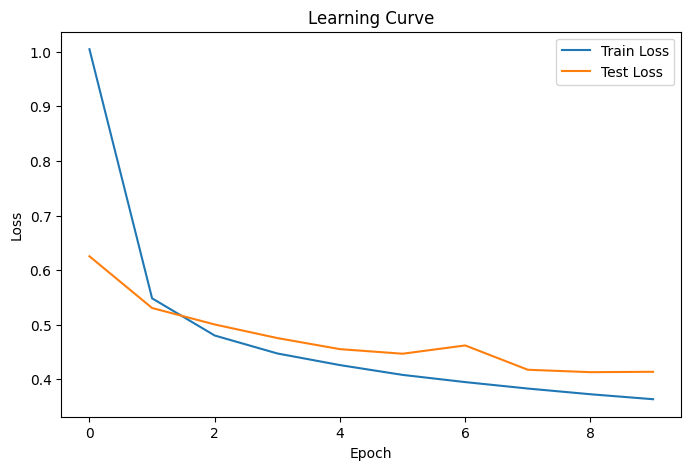

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Learning Curve")

plt.legend()

plt.show()

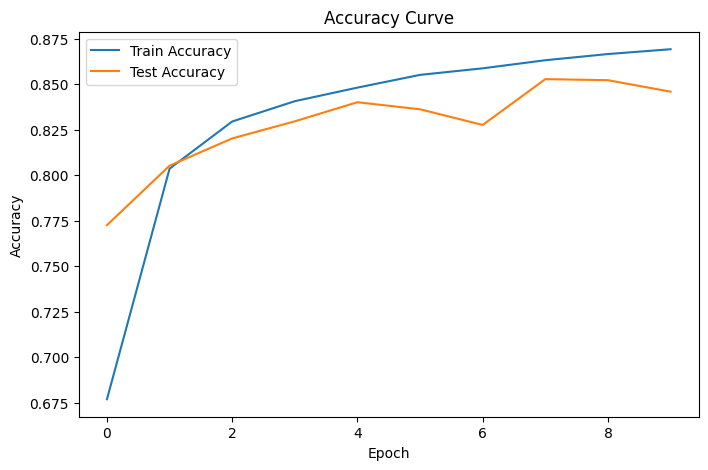

In [15]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")

plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve")

plt.legend()

plt.show()